**A Hybrid Method**

Numerical methods and deep learning can often complement each other when solving differential equations. A common strategy is to first approximate the solution with Euler's method and then refine it using a neural network.
We shall implement this method in the case of the simple ODE
$$\frac{dy}{dt} = y, \quad y(0) = 1,  $$
for which the exact solution is known, $y_{\rm exact} (t) =  e^t$.


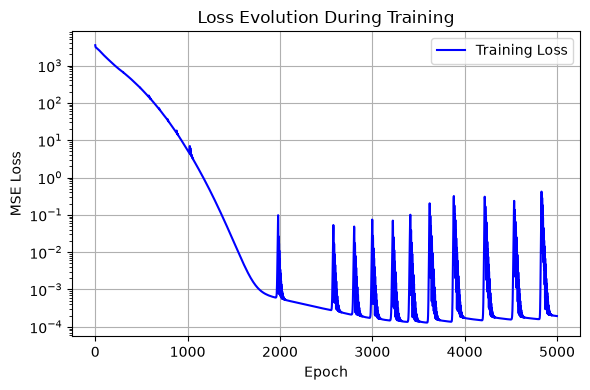

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


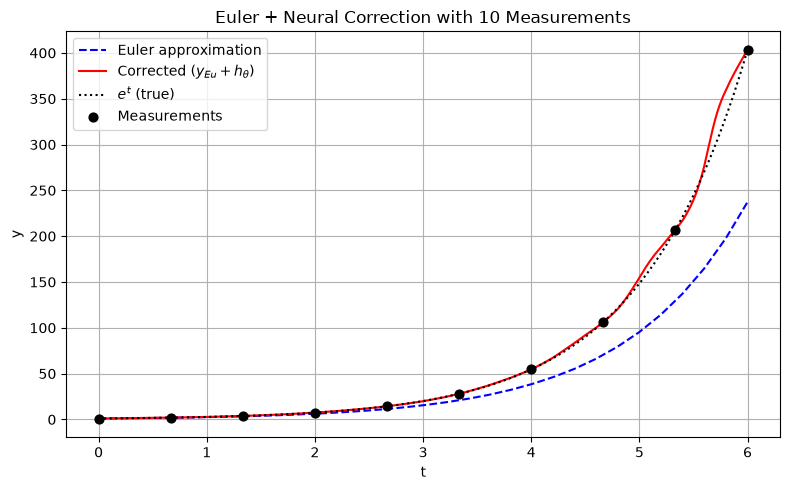

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
import matplotlib.pyplot as plt

# 1) Define domain and true solution
t_final = 6.0
dt = 0.2
t_eu = np.arange(0, t_final + dt, dt, dtype=np.float32)
y_true = np.exp(t_eu)

# 2) Euler approximation y_Eu on full grid
y_eu = np.zeros_like(t_eu)
y_eu[0] = 1.0
for i in range(len(t_eu)-1):
    y_eu[i+1] = y_eu[i] + dt * y_eu[i]

# 3) Measurements at 10 equidistant points
t_meas = np.linspace(0, t_final, 10, dtype=np.float32)
y_meas = np.exp(t_meas)
y_eu_meas = np.interp(t_meas, t_eu, y_eu)

# 4) Prepare training data: inputs = t_meas, targets = correction
t_train = t_meas.reshape(-1,1)
correction = (y_meas - y_eu_meas).reshape(-1,1)

# 5) Build correction network h_theta(t)
inp = layers.Input(shape=(1,))
x = layers.Dense(64, activation='tanh')(inp)
x = layers.Dense(32, activation='tanh')(x)
out = layers.Dense(1)(x)
model_h = Model(inp, out)

# 6) Compile and train on measurement data, saving history
model_h.compile(optimizer=optimizers.Adam(learning_rate=1e-2), loss='mse')
history = model_h.fit(t_train, correction, epochs=5000, verbose=0)

# 7) Plot loss evolution vs. epochs
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], 'b-', label='Training Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Evolution During Training')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 8) Evaluate on fine grid
t_fine = np.linspace(0, t_final, 300, dtype=np.float32).reshape(-1,1)
y_eu_fine = np.interp(t_fine.flatten(), t_eu, y_eu)
h_pred = model_h.predict(t_fine)
y_corr = y_eu_fine.reshape(-1,1) + h_pred
y_true_fine = np.exp(t_fine)

# 9) Plot results
plt.figure(figsize=(8,5))
plt.plot(t_fine, y_eu_fine, 'b--', label='Euler approximation')
plt.plot(t_fine, y_corr,   'r-',  label='Corrected ($y_{Eu}+h_\\theta$)')
plt.plot(t_fine, y_true_fine, 'k:', label='$e^t$ (true)')
plt.scatter(t_meas, y_meas, color='black', s=40, zorder=5, label='Measurements')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.title('Euler + Neural Correction with 10 Measurements')
plt.grid()
plt.tight_layout()
plt.show()